# Week 3 — Local Answer Generation Prototype

**Project:** BC Federal Labor Jurisdiction Engine  
**Environment:** Flowise 2.2.7 + Ollama + `qwen2.5:3b`

This notebook verifies the Week 3 generation layer by calling the local Flowise Prediction API, printing the generated answer, and displaying retrieved source-document metadata.


In [1]:
# Run once if requests is unavailable:
# %pip install requests

import json
from pathlib import Path
from typing import Any
import requests

FLOWISE_SERVER_URL = "http://localhost:3000"
CHATFLOW_ID = "197e3aa1-375d-4d7c-a9f4-0d5d14ae4199"                        #full    "f6fe772c-d6f9-4470-a3ad-0c8c9433e856"
OLLAMA_URL = "http://localhost:11434"

TIMEOUT_SECONDS = 300
FLOWISE_API_URL = f"{FLOWISE_SERVER_URL}/api/v1/prediction/{CHATFLOW_ID}"
HEADERS = {"Content-Type": "application/json"}


In [2]:
def check_service(url: str, name: str) -> None:
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        print(f"✅ {name} is reachable: {url}")
    except requests.RequestException as exc:
        raise RuntimeError(
            f"{name} is not reachable at {url}. "
            f"Start the service and rerun this cell. Original error: {exc}"
        ) from exc

if CHATFLOW_ID == "PASTE_EVALUATION_CHATFLOW_ID_HERE":
    raise ValueError(
        "Replace CHATFLOW_ID with the ID from the EVALUATION chatflow URL."
    )

check_service(f"{FLOWISE_SERVER_URL}/api/v1/ping", "Flowise")
check_service(f"{OLLAMA_URL}/api/tags", "Ollama")


✅ Flowise is reachable: http://localhost:3000/api/v1/ping
✅ Ollama is reachable: http://localhost:11434/api/tags


In [3]:
models_response = requests.get(f"{OLLAMA_URL}/api/tags", timeout=10)
models_response.raise_for_status()

installed_models = {
    item.get("name", "")
    for item in models_response.json().get("models", [])
}

print("Installed Ollama models:")
for model in sorted(installed_models):
    print(f"  - {model}")

required_prefixes = ["nomic-embed-text", "qwen2.5:3b"]
missing = [
    required
    for required in required_prefixes
    if not any(model.startswith(required) for model in installed_models)
]

if missing:
    raise RuntimeError(
        "Missing required Ollama model(s): " + ", ".join(missing)
    )

print("✅ Required Ollama models are available.")


Installed Ollama models:
  - nomic-embed-text:latest
  - qwen2.5:3b
✅ Required Ollama models are available.


## Main Week 3 query

The guide uses a banking scenario to test federal jurisdiction routing and citation output.


In [4]:
question = (
    "I work as a bank teller at an RBC branch in Vancouver. "
    "What is my minimum wage and where does it legally come from?"
)

payload = {
    "question": question,
    "overrideConfig": {
        "returnSourceDocuments": True
    }
}

print("⏳ Programmatically executing query via local Flowise...")
print(f"Question: {question}")
print(f"Endpoint: {FLOWISE_API_URL}")

try:
    response = requests.post(
        FLOWISE_API_URL,
        json=payload,
        headers=HEADERS,
        timeout=TIMEOUT_SECONDS
    )
except requests.exceptions.ReadTimeout as exc:
    raise RuntimeError(
        "The request timed out. Confirm that the EVALUATION chatflow "
        "uses the curated test corpus and has already been upserted."
    ) from exc

print(f"HTTP status: {response.status_code}")

if not response.ok:
    print("\nRaw response body:")
    print(response.text[:4000])
    response.raise_for_status()

data: dict[str, Any] = response.json()
print("✅ Flowise returned valid JSON.")


⏳ Programmatically executing query via local Flowise...
Question: I work as a bank teller at an RBC branch in Vancouver. What is my minimum wage and where does it legally come from?
Endpoint: http://localhost:3000/api/v1/prediction/197e3aa1-375d-4d7c-a9f4-0d5d14ae4199
HTTP status: 200
✅ Flowise returned valid JSON.


In [5]:
def extract_answer(response_data: dict[str, Any]) -> str:
    for key in ("text", "answer", "result", "output"):
        value = response_data.get(key)
        if isinstance(value, str) and value.strip():
            return value.strip()
    return ""

def extract_source_documents(
    response_data: dict[str, Any]
) -> list[dict[str, Any]]:
    for key in ("sourceDocuments", "source_documents", "documents", "sources"):
        value = response_data.get(key)
        if isinstance(value, list):
            return [item for item in value if isinstance(item, dict)]

    for parent_key in ("data", "result", "output"):
        nested = response_data.get(parent_key)
        if isinstance(nested, dict):
            for key in ("sourceDocuments", "source_documents", "documents", "sources"):
                value = nested.get(key)
                if isinstance(value, list):
                    return [item for item in value if isinstance(item, dict)]
    return []

answer = extract_answer(data)
source_documents = extract_source_documents(data)

print("\n🚨 API LOCAL PIPELINE CONNECTIVITY: VERIFIED ONLINE 🚨")
print("======================================================")

print("\n[Local AI Factual Answer]")
print("-------------------------")
print(answer if answer else "(No generated answer was returned.)")

print("\n[Retrieved Context Passage Validations]")
print("---------------------------------------")

if not source_documents:
    print("No source documents were returned.")
else:
    for index, document in enumerate(source_documents, 1):
        metadata = document.get("metadata", {})
        source_origin = (
            metadata.get("source")
            or metadata.get("filePath")
            or metadata.get("filename")
            or "Manual Ingest Block"
        )
        content = (
            document.get("pageContent")
            or document.get("text")
            or document.get("content")
            or ""
        )

        print(f"\nFile Match #{index}: {source_origin}")
        print("Content preview:")
        print(content[:800])



🚨 API LOCAL PIPELINE CONNECTIVITY: VERIFIED ONLINE 🚨

[Local AI Factual Answer]
-------------------------
The jurisdiction for your workplace, being an RBC bank branch located in Vancouver, is governed by the Canada Labour Code. According to Division IIMinimum Wage and Age of Employment:

178(2) If the minimum hourly rate that is fixed, from time to time, by or under an Act of the legislature of the province where the employee is usually employed and that is generally applicable regardless of occupation, status or work experience is higher than the minimum hourly rate fixed under subsection (1), an employer shall pay to each employee a wage at a rate that is...

(a) if the wages of the employee are paid on an hourly basis, not less than that higher minimum hourly rate; or

(b) fix a standard basis of work to which a minimum wage on a basis other than time may be applied.

Given your workplace in Vancouver, RBC (an interprovincial transportation company) is federally regulated under th

In [6]:
REFUSAL_TEXT = (
    "I cannot find a verified parameter for this specific jurisdiction "
    "layout within the official guides."
)

checks = {
    "answer_returned": bool(answer),
    "source_documents_returned": len(source_documents) > 0,
    "contains_source_label": "source:" in answer.lower(),
    "contains_placeholder_section": (
        "section xx" in answer.lower()
        or "section xxx" in answer.lower()
    ),
    "incorrect_bc_source_for_bank_query": (
        "bc employment standards" in answer.lower()
        or "bc esa" in answer.lower()
    ),
    "triggered_refusal": REFUSAL_TEXT.lower() in answer.lower()
}

print("Week 3 Prototype Check Results:")
for name, value in checks.items():
    print(f"  {name}: {value}")

if checks["contains_placeholder_section"]:
    print(
        "\n⚠️ The model copied a placeholder citation. "
        "Remove Section XX/XXX examples from the Response Prompt."
    )

if checks["incorrect_bc_source_for_bank_query"]:
    print(
        "\n⚠️ The banking query appears to use a BC source. "
        "Review the retrieved federal documents and jurisdiction prompt."
    )


Week 3 Prototype Check Results:
  answer_returned: True
  source_documents_returned: True
  contains_source_label: False
  contains_placeholder_section: False
  incorrect_bc_source_for_bank_query: False
  triggered_refusal: False


## Optional three-scenario validation

Use these tests after the main query works. Keep both successes and failures for Week 4 error analysis.


In [7]:
test_cases = [
    {
        "id": "BC_PAID_SICK_LEAVE",
        "question": (
            "I work in a retail store in Vancouver. "
            "How many paid sick days am I entitled to?"
        )
    },
    {
        "id": "FEDERAL_BANKING",
        "question": (
            "I work as a bank teller at RBC in Vancouver. "
            "Which jurisdiction and minimum wage rules apply to me?"
        )
    },
    {
        "id": "CROSS_JURISDICTION_REFUSAL",
        "question": (
            "I work at a local restaurant in Vancouver. "
            "Can I use the Canada Labour Code paid leave rules?"
        )
    }
]

prototype_results = []

for test_case in test_cases:
    print("\n" + "=" * 70)
    print(f"TEST: {test_case['id']}")
    print(f"Question: {test_case['question']}")

    test_payload = {
        "question": test_case["question"],
        "overrideConfig": {
            "returnSourceDocuments": True
        }
    }

    try:
        test_response = requests.post(
            FLOWISE_API_URL,
            json=test_payload,
            headers=HEADERS,
            timeout=TIMEOUT_SECONDS
        )
        test_response.raise_for_status()
        test_data = test_response.json()

        test_answer = extract_answer(test_data)
        test_sources = extract_source_documents(test_data)

        print("\nAnswer:")
        print(test_answer)

        print("\nSources:")
        source_names = []
        for source_index, document in enumerate(test_sources, 1):
            metadata = document.get("metadata", {})
            source_name = (
                metadata.get("source")
                or metadata.get("filePath")
                or metadata.get("filename")
                or "Manual Ingest Block"
            )
            source_names.append(source_name)
            print(f"  {source_index}. {source_name}")

        prototype_results.append({
            "id": test_case["id"],
            "question": test_case["question"],
            "answer": test_answer,
            "sources": source_names,
            "status": "success"
        })

    except requests.exceptions.ReadTimeout:
        print("❌ Request timed out.")
        prototype_results.append({
            "id": test_case["id"],
            "question": test_case["question"],
            "answer": "",
            "sources": [],
            "status": "timeout"
        })

    except requests.RequestException as exc:
        print(f"❌ Request failed: {exc}")
        prototype_results.append({
            "id": test_case["id"],
            "question": test_case["question"],
            "answer": "",
            "sources": [],
            "status": f"request_error: {exc}"
        })



TEST: BC_PAID_SICK_LEAVE
Question: I work in a retail store in Vancouver. How many paid sick days am I entitled to?

Answer:
Based on the provided context, which pertains to BC provincial employment standards, full-time, part-time, and casual employees are entitled to 5 paid sick days after 90 days of continuous employment. This information is derived from Section 49.1(3) in Document ID '0'.

Sources:
  1. D:\AI_Project\data_corpus_week2_test\bc\bc_employment_guide_illness_injury_leave.docx
  2. D:\AI_Project\data_corpus_week2_test\bc\bc_employment_guide_illness_injury_leave.docx

TEST: FEDERAL_BANKING
Question: I work as a bank teller at RBC in Vancouver. Which jurisdiction and minimum wage rules apply to me?

Answer:
For a federally regulated worker like you, who works as a bank teller at RBC in British Columbia, the applicable jurisdiction is Canada Federal (federally). The specific section from the retrieved context that addresses your situation is:

Canada Labour Code — Minimum W

In [8]:
output_path = Path("week3_prototype_results.json")

with output_path.open("w", encoding="utf-8") as file:
    json.dump(
        prototype_results,
        file,
        indent=2,
        ensure_ascii=False
    )

print(f"✅ Saved prototype results to: {output_path.resolve()}")


✅ Saved prototype results to: C:\Users\sinotruk\Documents\BC_Federal_Labor_RAG_Week1_Week2\BC_Federal_Labor_RAG_Week1_Week2\week3_prototype_results.json


## Screenshot evidence

Capture a screenshot containing:

- `HTTP status: 200`
- `[Local AI Factual Answer]`
- the citation line
- `[Retrieved Context Passage Validations]`
- at least one real source filename


# Figure 1. Local Flowise and Ollama environment verification

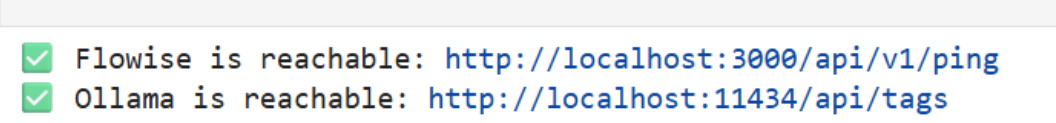

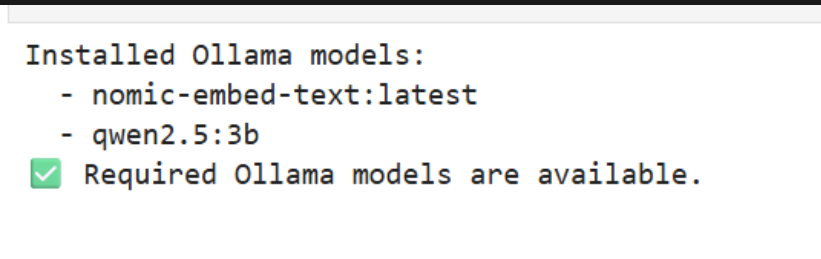

# Figure 2. Successful execution through the local Flowise Prediction API

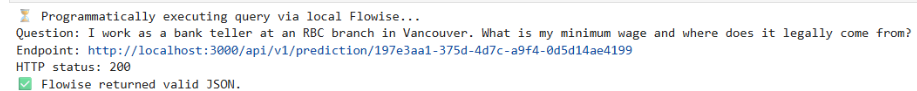

# Figure 3. Provincial, federal, and cross-jurisdiction guardrail validation

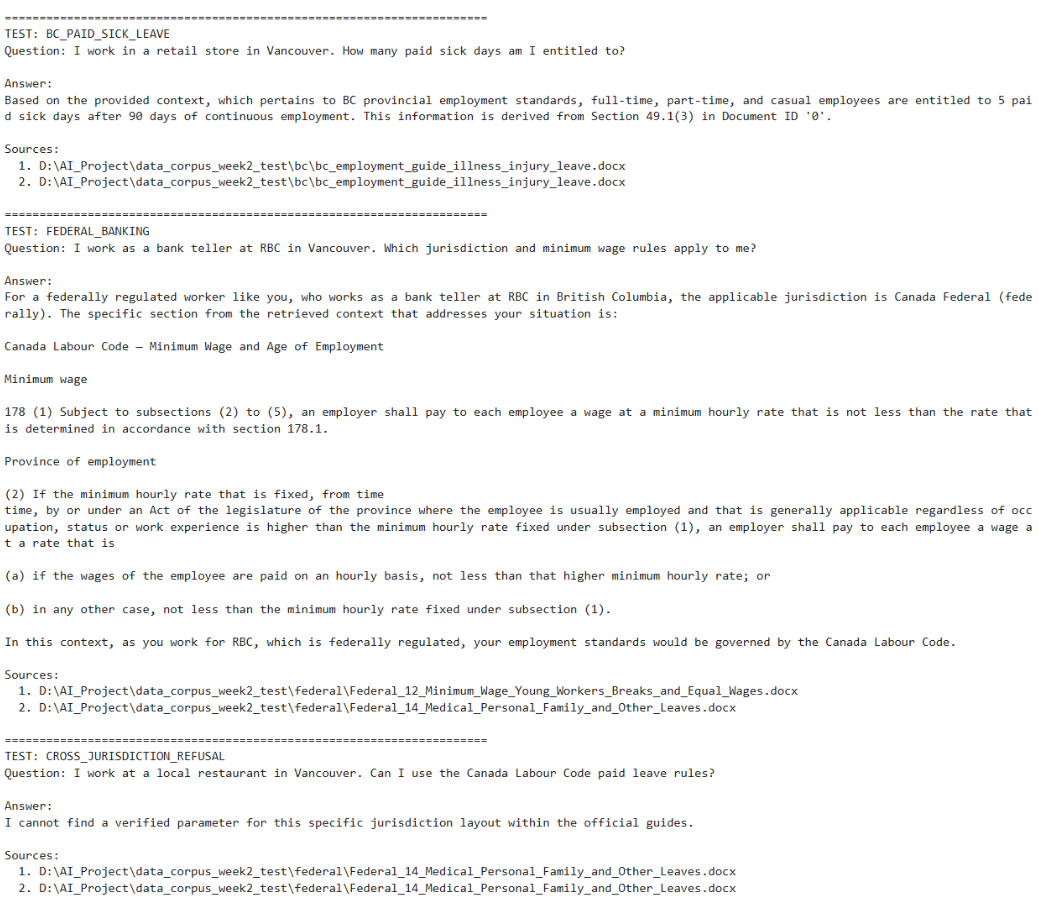

# Figure 4. Week 3 prototype results exported to JSON

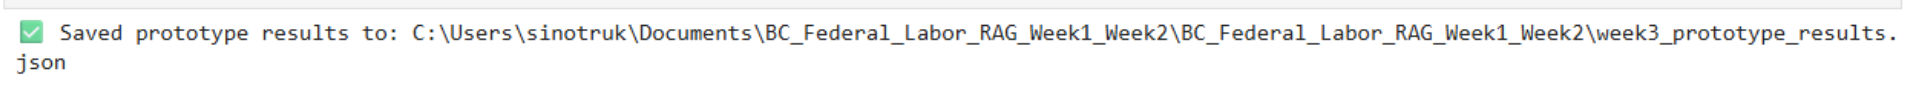

## Week 3 Results

The local Flowise and Ollama services were successfully connected, and both
the embedding model and local language model were available. The Evaluation
Chatflow was called through the local Prediction API and returned HTTP status
200.

Three prototype scenarios were tested: a BC provincial employment question,
a federally regulated banking question, and a cross-jurisdiction trick
question. The system retrieved source documents from the appropriate corpus
folders and successfully triggered the required refusal response for the
cross-jurisdiction case.

Some citation-format and generation errors remained and were retained for
Week 4 error analysis.